<a href="https://colab.research.google.com/github/Kaveeshamalindi/Sentiment-Analysis-using-NLP/blob/main/Sentiment_Analysis_using_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Pandas and Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv("/content/sample_data/Tweets.csv")

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## Check the Dataset

In [4]:
df.shape

(14640, 15)

In [5]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

In [6]:
df.groupby("airline_sentiment").describe()

tweet_id                                            \
                     count          mean           std           min   
airline_sentiment                                                      
negative            9178.0  5.692602e+17  7.572474e+14  5.675900e+17   
neutral             3099.0  5.691841e+17  8.068405e+14  5.675883e+17   
positive            2363.0  5.691006e+17  8.112476e+14  5.676555e+17   

                                                                           \
                            25%           50%           75%           max   
airline_sentiment                                                           
negative           5.686511e+17  5.695355e+17  5.698798e+17  5.703106e+17   
neutral            5.684852e+17  5.693080e+17  5.699305e+17  5.703093e+17   
positive           5.684331e+17  5.691980e+17  5.698788e+17  5.703093e+17   

                  airline_sentiment_confidence            ...  \
                                         count      mean  ...   
airline_sentiment                                         ...   
negative                                9178.0  0.933365  ...   
neutral                                 3099.0  0.823303  ...   
positive                                2363.0  0.872039  ...   

                  negativereason_confidence      retweet_count            \
                                        75%  max         count      mean   
airline_sentiment                                                          
negative                                1.0  1.0        9178.0  0.093375   
neutral                                 0.0  0.0        3099.0  0.060987   
positive                                0.0  0.0        2363.0  0.069403   

                                                       
                        std  min  25%  50%  75%   max  
airline_sentiment                                      
negative           0.792865  0.0  0.0  0.0  0.0  44.0  
neutral            0.658037  0.0  0.0  0.0  0.0  28.0  
positive           0.659914  0.0  0.0  0.0  0.0  22.0  

[3 rows x 32 columns]

In [42]:
df[df["airline_sentiment"] == "neutral"]["text"].nunique()

3067

## Keep Only Required Columns

In [7]:
df = df[["airline_sentiment", "text"]]

df.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


## Check Sentiment Distribution

In [8]:
df["airline_sentiment"].value_counts()

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


<Axes: xlabel='airline_sentiment'>

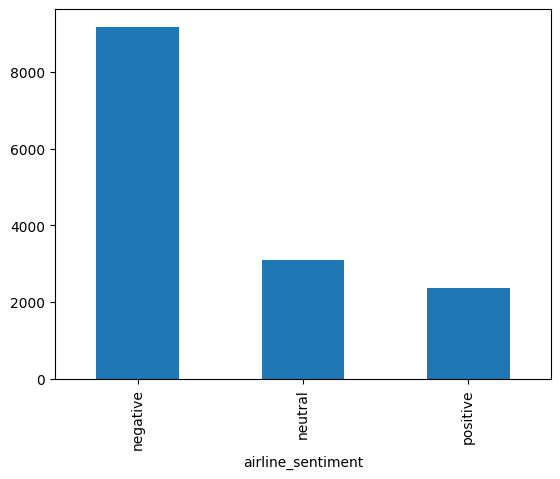

In [9]:
df["airline_sentiment"].value_counts().plot(kind="bar")

## Install / Import NLP Libraries

In [10]:
import nltk
import string
import re

from nltk.stem.porter import PorterStemmer

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.corpus import stopwords

ps = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Create the Text Cleaning Function
**The function:**

- converts text to lowercase
- removes URLs
- tokenizes words
- removes English stopwords
- applies stemming

In [11]:
def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Tokenize
    text = nltk.word_tokenize(text)

    # Remove stopwords
    y = []

    for i in text:
        if i not in stopwords.words("english"):
            y.append(i)

    # Stemming
    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

## Test the Function

In [12]:
clean_text("I really love this amazing airline!")

'realli love amaz airlin !'

In [41]:
clean_text("@VirginAmerica What @dhepburn said.")

'@ virginamerica @ dhepburn said .'

## Clean All Tweets

In [13]:
df["text_cleaned"] = df["text"].apply(clean_text)

In [14]:
df.head()

,airline_sentiment,text,text_cleaned
0,neutral,@VirginAmerica What @dhepburn said.,@ virginamerica @ dhepburn said .
1,positive,@VirginAmerica plus you've added commercials t...,@ virginamerica plu 've ad commerci experi ......
2,neutral,@VirginAmerica I didn't today... Must mean I n...,@ virginamerica n't today ... must mean need t...
3,negative,@VirginAmerica it's really aggressive to blast...,@ virginamerica 's realli aggress blast obnoxi...
4,negative,@VirginAmerica and it's a really big bad thing...,@ virginamerica 's realli big bad thing


## Check for Missing Values

In [15]:
df.isnull().sum()

,0
airline_sentiment,0
text,0
text_cleaned,0


In [16]:
df = df.dropna()

## Feature Extraction Using TF-IDF

### Import TfidfVectorizer

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

### Create the vectorizer with 3000 maximum features, as required

In [18]:
tfidf = TfidfVectorizer(max_features=3000)

### Fit it to the cleaned tweets and transform them

In [19]:
X = tfidf.fit_transform(df["text_cleaned"]).toarray()

### Now X contains the numerical representation of the tweets

In [20]:
X.shape

(14640, 3000)

## Create Y

In [21]:
Y = df["airline_sentiment"].values

In [22]:
Y[:10]

array(['neutral', 'positive', 'neutral', 'negative', 'negative',
       'negative', 'positive', 'neutral', 'positive', 'positive'],
      dtype=object)

## Split Training and Testing Data

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=2
)

In [25]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (11712, 3000)
Testing data: (2928, 3000)


## Train Multinomial Naïve Bayes

## Import the model and accuracy metric

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

### Create the model

In [27]:
model_nb = MultinomialNB()

## Train it

In [28]:
model_nb.fit(X_train, y_train)

MultinomialNB()

## Predict

In [29]:
y_pred_nb = model_nb.predict(X_test)

## Calculate accuracy

In [30]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.7219945355191257


## Train Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
model_rf = RandomForestClassifier()

In [33]:
model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [34]:
y_pred_rf = model_rf.predict(X_test)

In [35]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7520491803278688


## Compare Both Models

In [36]:
print("Multinomial Naive Bayes:", accuracy_nb)
print("Random Forest:", accuracy_rf)

Multinomial Naive Bayes: 0.7219945355191257
Random Forest: 0.7520491803278688


## Test the Model with Your Own Tweet

In [37]:
tweet = ["I had an amazing flight and the staff were very friendly!"]

In [38]:
tweet_cleaned = [clean_text(tweet[0])]

In [39]:
tweet_vector = tfidf.transform(tweet_cleaned).toarray()

In [40]:
prediction = model_nb.predict(tweet_vector)

print("Predicted sentiment:", prediction[0])

Predicted sentiment: positive
